In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/zomato_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (51696, 19)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city,cuisine_count,primary_cuisine
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,3.0,North Indian
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,3.0,Chinese
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.0,Cafe
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,2.0,South Indian
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,2.0,North Indian


In [3]:
df_model = df[df['rate'].notna()].copy()
df_model['is_successful'] = (df_model['rate'] >= 4.0).astype(int)

print("Successful restaurants:", df_model['is_successful'].sum())
print("Not successful:", (df_model['is_successful'] == 0).sum())
print("Success rate:", round(df_model['is_successful'].mean() * 100, 1), "%")

Successful restaurants: 12399
Not successful: 29266
Success rate: 29.8 %


In [4]:
le = LabelEncoder()

df_model['location_encoded'] = le.fit_transform(df_model['location'])
df_model['rest_type_encoded'] = le.fit_transform(df_model['rest_type'])
df_model['primary_cuisine_encoded'] = le.fit_transform(df_model['primary_cuisine'])

features = [
    'online_order',
    'book_table', 
    'votes',
    'cost_for_two',
    'cuisine_count',
    'location_encoded',
    'rest_type_encoded',
    'primary_cuisine_encoded'
]

X = df_model[features]
y = df_model['is_successful']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (41665, 8)
Target distribution:
 is_successful
0    29266
1    12399
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training success rate:", round(y_train.mean() * 100, 1), "%")
print("Testing success rate:", round(y_test.mean() * 100, 1), "%")

Training set size: (33332, 8)
Testing set size: (8333, 8)
Training success rate: 29.8 %
Testing success rate: 29.6 %


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model trained successfully")

y_pred = rf_model.predict(X_test)
accuracy = rf_model.score(X_test, y_test)
print(f"Model Accuracy: {round(accuracy * 100, 1)}%")

Model trained successfully
Model Accuracy: 91.4%


                precision    recall  f1-score   support

Not Successful       0.91      0.98      0.94      5866
    Successful       0.94      0.76      0.84      2467

      accuracy                           0.91      8333
     macro avg       0.92      0.87      0.89      8333
  weighted avg       0.92      0.91      0.91      8333



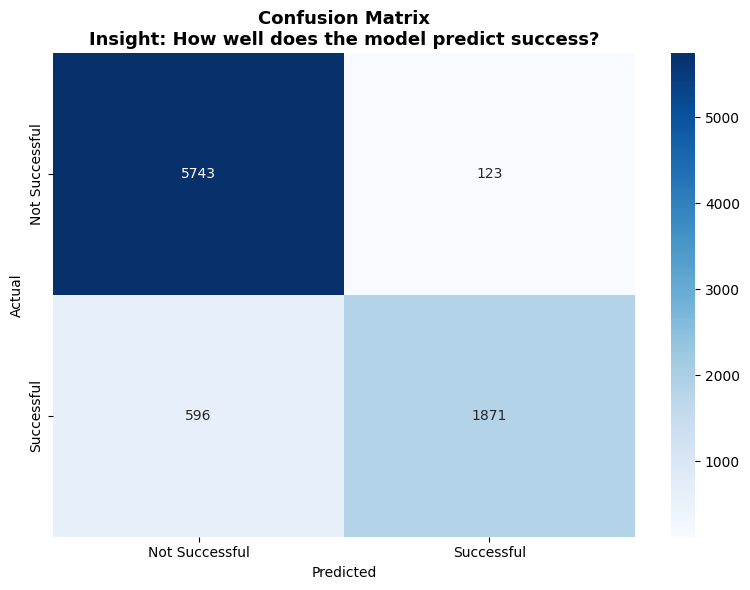

In [7]:
print(classification_report(y_test, y_pred, 
      target_names=['Not Successful', 'Successful']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix\nInsight: How well does the model predict success?',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

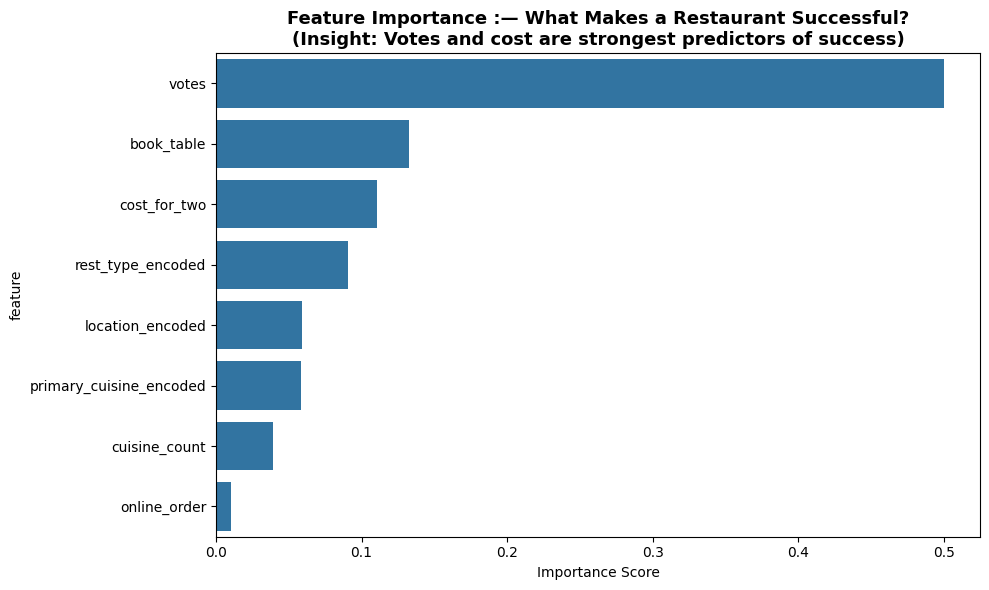

                   feature  importance
2                    votes    0.499730
1               book_table    0.132415
3             cost_for_two    0.110733
6        rest_type_encoded    0.090472
5         location_encoded    0.058951
7  primary_cuisine_encoded    0.058567
4            cuisine_count    0.038895
0             online_order    0.010236


In [10]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance :— What Makes a Restaurant Successful?\n'
          '(Insight: Votes and cost are strongest predictors of success)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance)

In [12]:
def predict_success(online_order, book_table, votes, cost_for_two,
                    cuisine_count, location, rest_type, primary_cuisine):
    
    try:
        loc_enc = le.transform([location])[0]
    except:
        loc_enc = 0
    try:
        rest_enc = le.transform([rest_type])[0]
    except:
        rest_enc = 0
    try:
        cuisine_enc = le.transform([primary_cuisine])[0]
    except:
        cuisine_enc = 0
    
    input_data = pd.DataFrame([[
        online_order, book_table, votes, cost_for_two,
        cuisine_count, loc_enc, rest_enc, cuisine_enc
    ]], columns=features)
    
    probability = rf_model.predict_proba(input_data)[0][1]
    prediction = rf_model.predict(input_data)[0]
    
    print(f"Success Probability: {round(probability * 100, 1)}%")
    print(f"Prediction: {'Likely Successful' if prediction == 1 else '❌ Unlikely Successful'}")
    return probability

predict_success(
    online_order=1,
    book_table=1,
    votes=500,
    cost_for_two=800,
    cuisine_count=3,
    location='Koramangala 5th Block',
    rest_type='Casual Dining',
    primary_cuisine='North Indian'
)

Success Probability: 58.0%
Prediction: Likely Successful


np.float64(0.5802822899238862)

In [13]:
predict_success(
    online_order=0,
    book_table=0,
    votes=10,
    cost_for_two=200,
    cuisine_count=1,
    location='Koramangala 5th Block',
    rest_type='Quick Bites',
    primary_cuisine='North Indian'
)

Success Probability: 3.8%
Prediction: ❌ Unlikely Successful


np.float64(0.03848692885102353)

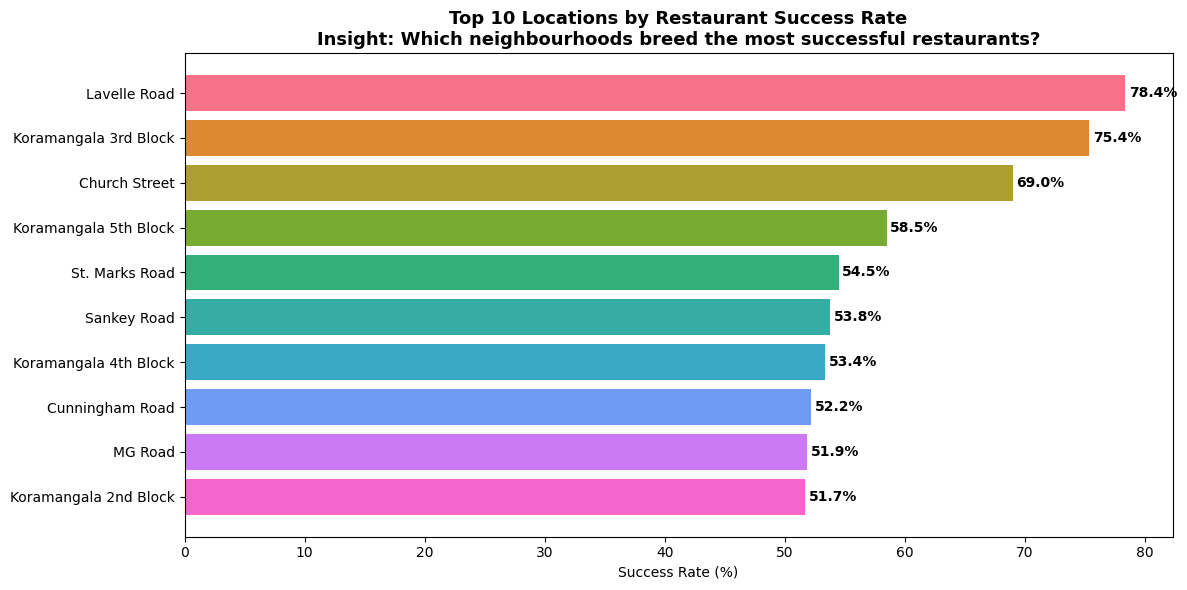

In [14]:
location_success = (df_model.groupby('location')
                    .agg(total=('is_successful', 'count'),
                         successful=('is_successful', 'sum'))
                    .query('total >= 20')
                    .assign(success_rate=lambda x: 
                            round(x['successful'] / x['total'] * 100, 1))
                    .sort_values('success_rate', ascending=False)
                    .head(10)
                    .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(location_success['location'],
                location_success['success_rate'],
                color=sns.color_palette("husl", 10))
for bar, val in zip(bars, location_success['success_rate']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')
plt.xlabel('Success Rate (%)')
plt.title('Top 10 Locations by Restaurant Success Rate\n'
          'Insight: Which neighbourhoods breed the most successful restaurants?',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

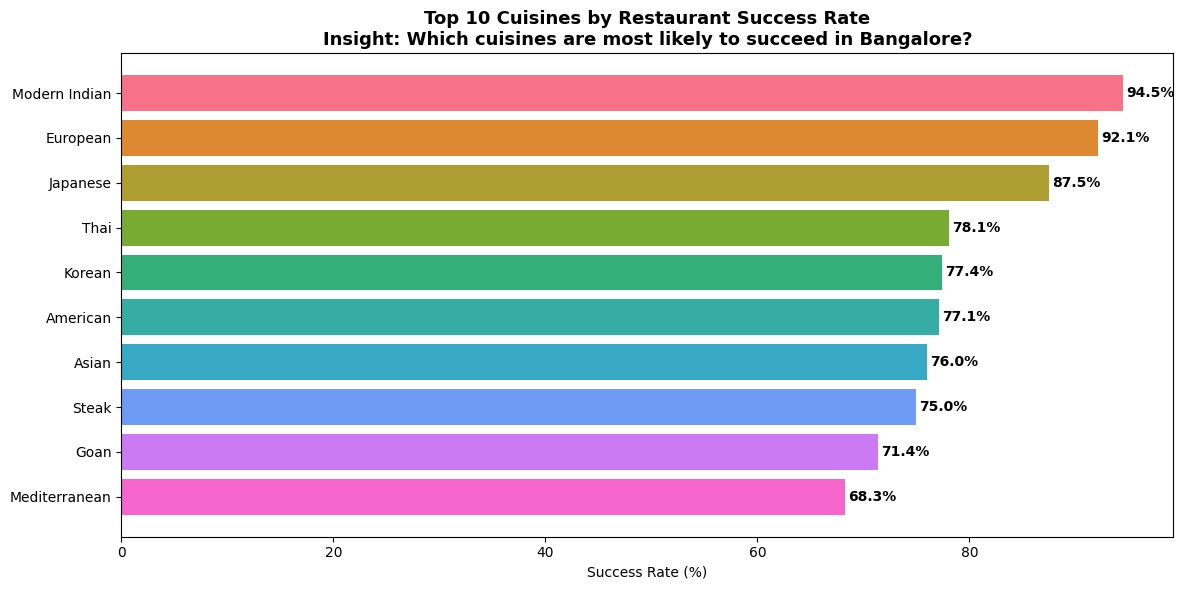

In [15]:
cuisine_success = (df_model[df_model['primary_cuisine'] != 'Unknown']
                   .groupby('primary_cuisine')
                   .agg(total=('is_successful', 'count'),
                        successful=('is_successful', 'sum'))
                   .query('total >= 30')
                   .assign(success_rate=lambda x: 
                           round(x['successful'] / x['total'] * 100, 1))
                   .sort_values('success_rate', ascending=False)
                   .head(10)
                   .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(cuisine_success['primary_cuisine'],
                cuisine_success['success_rate'],
                color=sns.color_palette("husl", 10))
for bar, val in zip(bars, cuisine_success['success_rate']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')
plt.xlabel('Success Rate (%)')
plt.title('Top 10 Cuisines by Restaurant Success Rate\n'
          'Insight: Which cuisines are most likely to succeed in Bangalore?',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()